# **СТАТИСТИЧЕСКИЙ АНАЛИЗ И ОБРАБОТКА ДАННЫХ**

Грамотная обработка и анализ данных имеют решающую роль в статистике и машинном обучении. Многочисленные ошибки при заполнении данных, пропуски, выбросы, дубликаты - все это оказывает сильное влияние на будущие прогнозы моделей.

Ошибки в данных могут возникать по разным причинам: человеческий фактор, сбои в системах, некорректная запись данных. Пропуски данных встречаются, когда информация по тем или иным причинам недоступна, а выбросы могут быть следствием технических проблем или представлять собой экстремальные значения, которые не характерны для нормального поведения системы. Если такие аномалии не будут обнаружены и обработаны на этапе предобработки, они могут повлиять на результаты моделей машинного обучения, приводя к искажениям или неправильным выводам.

Дубликаты данных, возникающие при многократной записи одних и тех же данных, также могут исказить анализ и привести к завышенным или заниженным оценкам. Поэтому важно выявлять такие дубликаты и устранять их.

Чем тщательнее будет проведена предобработка данных, тем выше вероятность того, что будущие модели машинного обучения или нейронные сети смогут строить точные прогнозы и выявлять скрытые закономерности. В процессе предобработки данных необходимо не только устранять ошибки и аномалии, но и преобразовывать данные в удобный для моделирования формат.


##### В этом задании вы будете работать с известным датасетом вина. Вам предстоит выполнить различные шаги, включающие статистический анализ и очистку данных. **Следуйте инструкциям для каждого раздела, выполняйте код и анализируйте результаты**.

## **ОПИСАНИЕ ДАННЫХ**

#### Этот набора данных относятся к красной разновидностям португальского вина «Винью Верде». В данных представлены физико-химические (входные) и сенсорные (выходные) характеристики (например, нет данных о сортах винограда, марке вина, цене продажи вина и т. д.).

##### Ваша задача - максимально очистить данные от выбросов, пропусков и различных ошибок. Также необходимо масштабировать все признаки

In [ ]:
import pandas as pd # Для работы с данными
from scipy import stats # Статистика
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import spearmanr
import numpy as np

import matplotlib.pyplot as plt # Для визуализации (вариант 1)
import seaborn as sns # Для визуализации (вариант 2)

from phik import resources, phik_matrix # Для построения нелинейной корреляции

## **Блок 1: Проверка данных**

#### 1.1 Загрузите данные с помощью библиотеки Pandas

In [ ]:
data = pd.read_csv("homework_1.csv")
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,-7.4,0.70,0.00,-,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.2,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,-,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,-,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


#### 1.2 Взгляните на типы данных каждого свойства

In [ ]:
data.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar           object
chlorides               float64
free_sulfur_dioxide      object
total_sulfur_dioxide     object
density                  object
pH                       object
sulphates               float64
alcohol                  object
quality                  object
dtype: object

#### 1.3 Исследуйте данные на наличие ошибок в типах данных. Если таковые имеются - исправьте и укажите необходимый тип данных

In [ ]:
data.replace({'-': np.nan, '?': np.nan, '--': np.nan, 'fix': np.nan, '1.zero': 1, 'nine': 9, 'six': 6}, inplace=True)
data['residual_sugar'] = data['residual_sugar'].astype(float)
data['free_sulfur_dioxide'] = data['free_sulfur_dioxide'].astype(float)
data['total_sulfur_dioxide'] = data['total_sulfur_dioxide'].astype(float)
data['density'] = data['density'].astype(float)
data['pH'] = data['pH'].astype(float)
data['alcohol'] = data['alcohol'].astype(float)
data['quality'] = data['quality'].astype(float)
data.dtypes


fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
dtype: object

##### PS: Чтобы конвертировать один тип данных в другой можете использовать
            df['название_столбца'] = df['название_столбца'].astype(типа_данных)

##### Более подробнее вы можете прочитать об этом здесь https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html

#### **Сделайте вывод**:

В наборе данных содержится некоторое количество "неудобных значений", например "nine", "six", "1.zero", или обычные пропуски. Такие значения были заменены на соответсвующие числовые или записаны как NaN.
Для всех свойств вина необходимо указать тип данных float.

## **Блок 2: Детектирование и очистка выбросов**

#### 2.1 С помощью методов визуализации выведите гистограммы (или box plot) для всех свойств. У каких свойств имеются выбросы? Предположите из-за чего они могли появиться

##### PS: Используйте seaborn или matplotlib. Можете сделать цикл, которые будет выводить графики, чтобы не отрисовывать их вручную

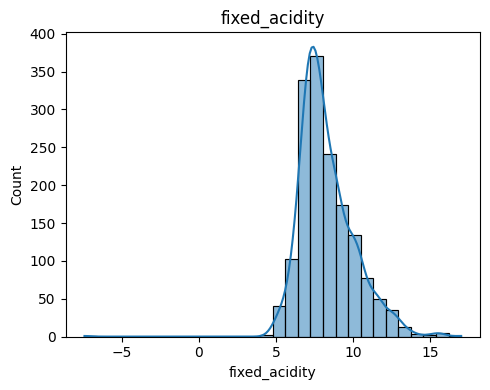

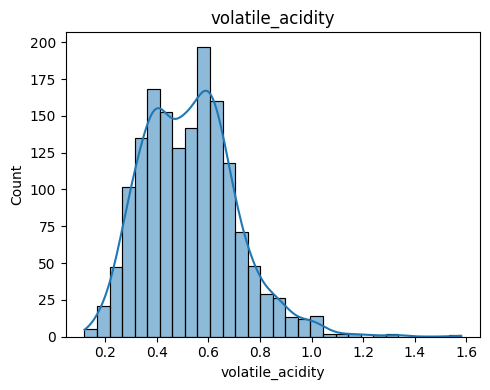

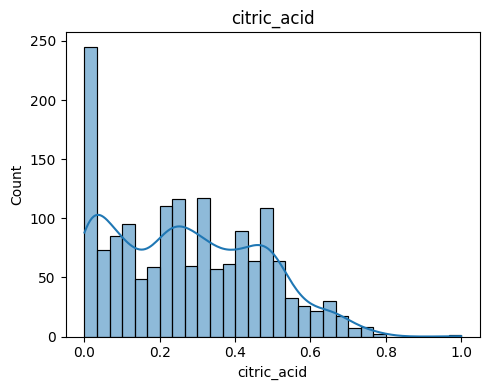

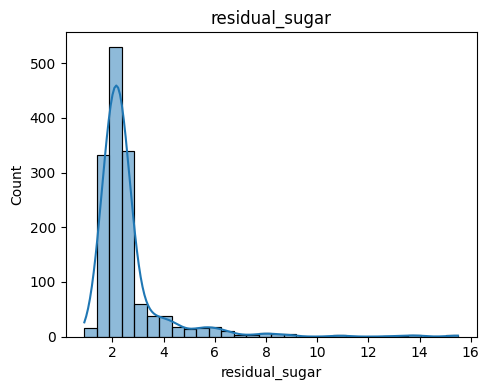

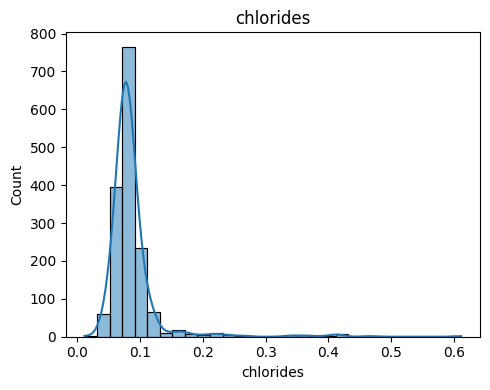

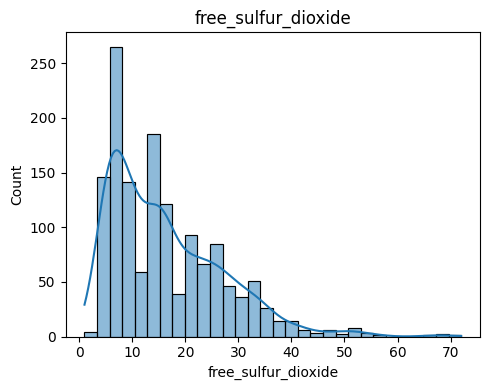

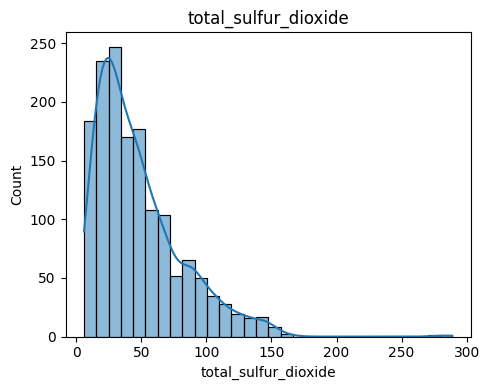

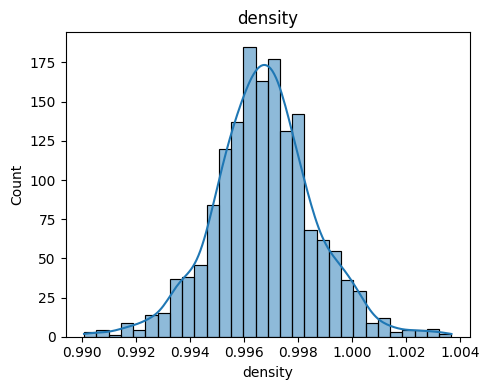

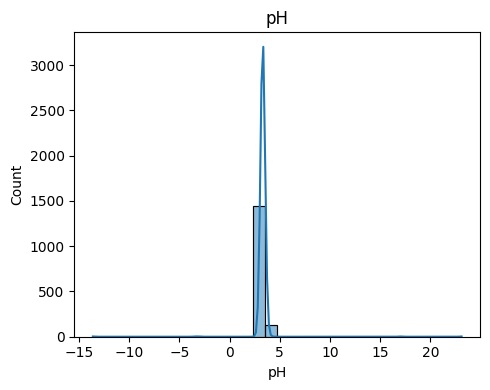

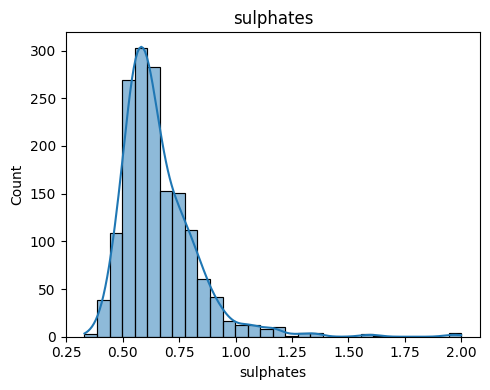

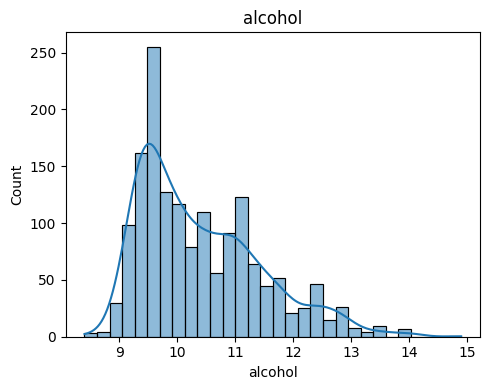

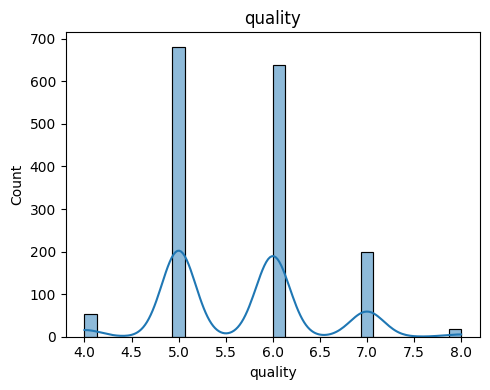

In [ ]:
# Строю распределение всех признаков
for column in data.columns:
    plt.figure(figsize=(5, 4))
    sns.histplot(data[column], bins=30, kde=True)
    plt.title(column)
    plt.tight_layout()
    plt.show()

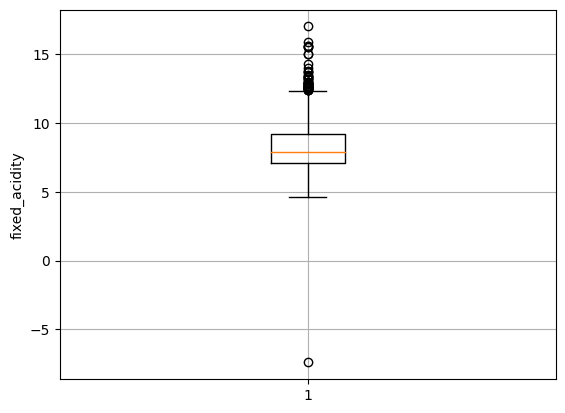

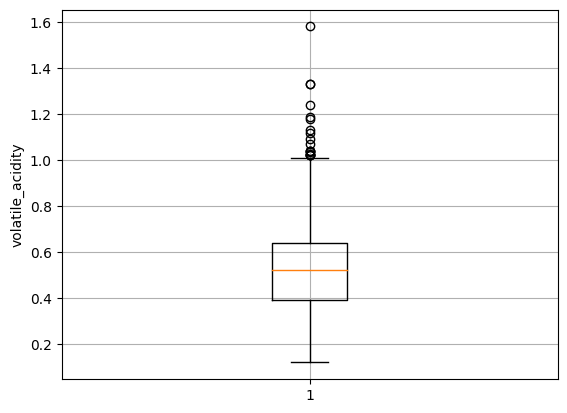

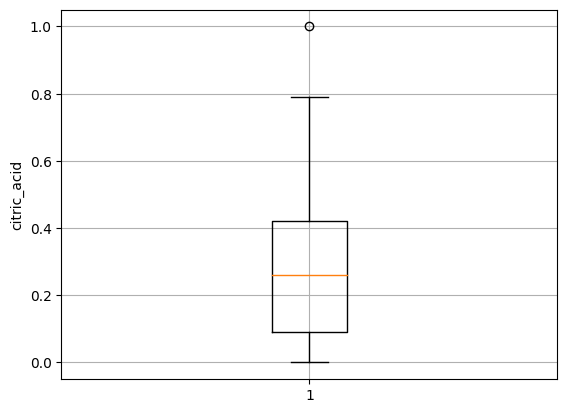

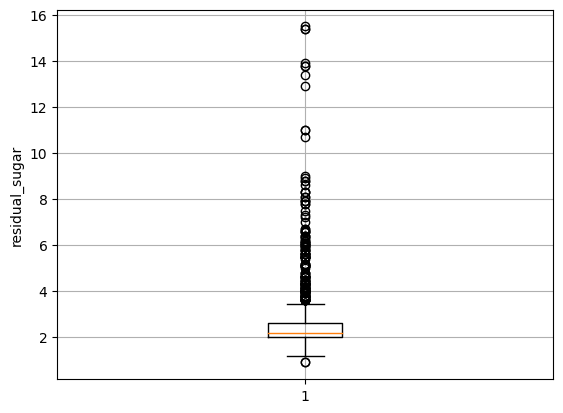

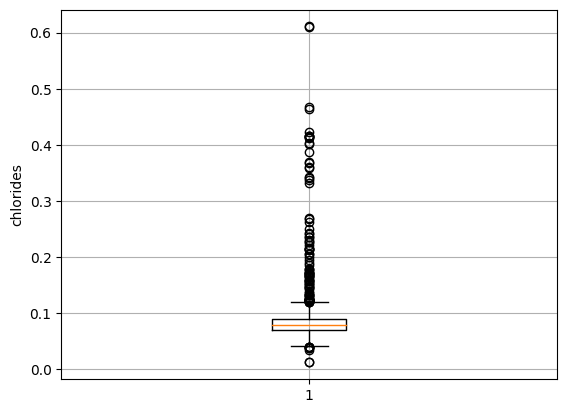

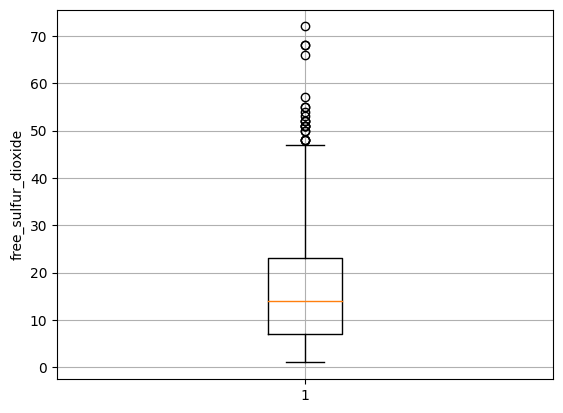

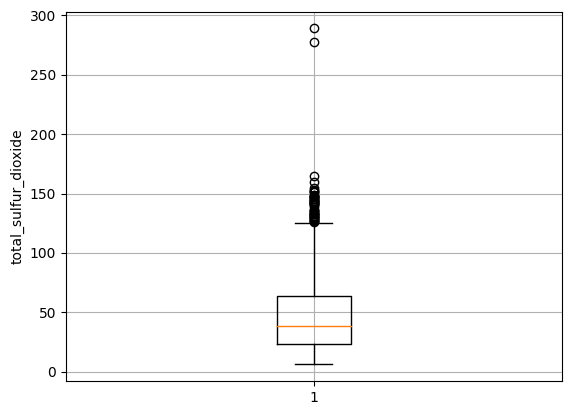

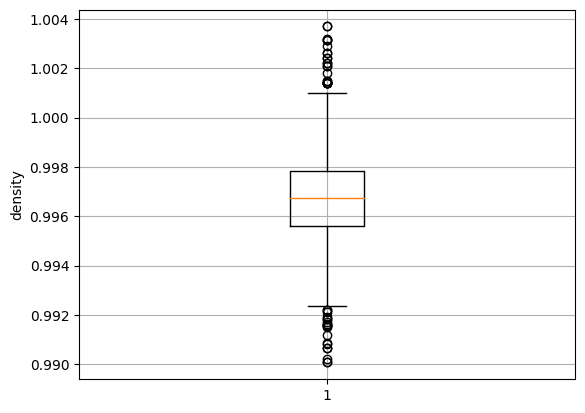

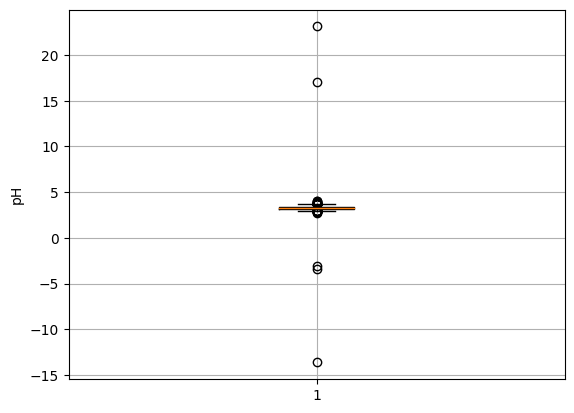

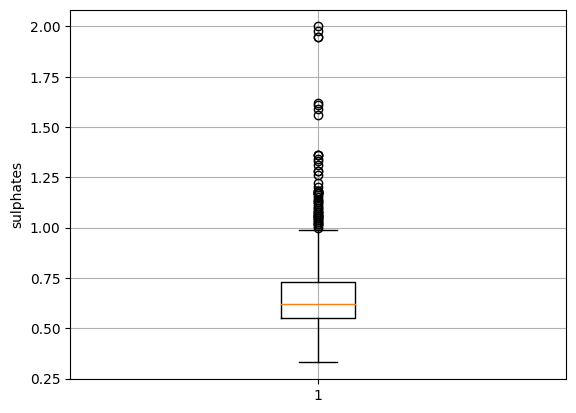

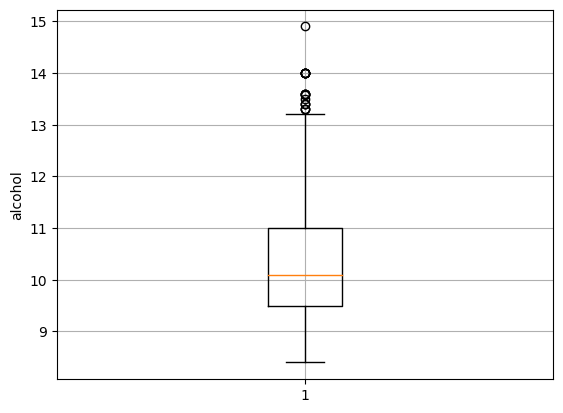

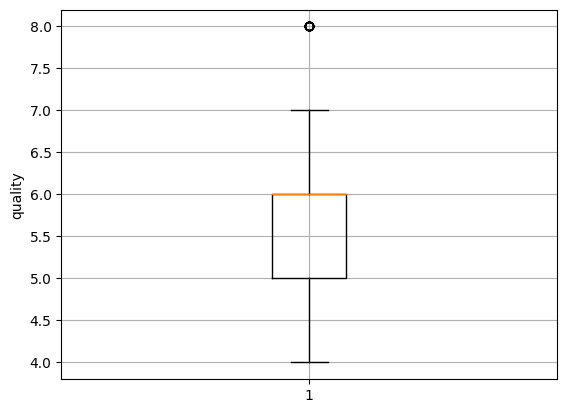

In [ ]:
for column in data.columns:
    plt.boxplot(data[column].dropna())
    plt.ylabel(column)
    plt.grid()
    plt.show()

#### 2.2 Разберитесь с выбросами путем их удаления, либо заменой значений, либо любым другим методом, который вы знаете

In [ ]:
for column in data.columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    min = Q1 - 1.5 * IQR
    max = Q3 + 1.5 * IQR
    median = data[column].median()
    data[column] = np.where((data[column] < min) | (data[column] > max), median, data[column])


#### **Сделайте вывод**:

В данном пункте я решил заменить выбросы на медиану с помощью интерквартильного размаха. Я решил выбрать именно медиану, так как не все признаки имеют симметричное распределение (хотя многие и похожи на него), медиана более усойчива к выбросам и она лучше отображает "центральную" тенденцию. Мода не подойдет, так как она больше используется для категориальных признаков (у нас таковых нет), а среднее не хочу использовать из-за большого количества выбросов в некоторых признаках (среднее сильно исказится).

## **Блок 3: Работа с пропусками**

#### 3.1 Выведите общее, среднее **и** суммарное количество пропусков в колонках

In [ ]:
nans = []
for column in data.columns:
    print(column)
    print(data[column].isnull().sum())
    nans.append(data[column].isnull().sum())
print(f'Общее число пропусков: {sum(nans)}')
print(f'Среднее число пропусков: {sum(nans)/len(nans)}')


fixed_acidity
7
volatile_acidity
0
citric_acid
0
residual_sugar
144
chlorides
0
free_sulfur_dioxide
175
total_sulfur_dioxide
80
density
0
pH
21
sulphates
0
alcohol
21
quality
10
Общее число пропусков: 458
Среднее число пропусков: 38.166666666666664


#### 3.2 Разберитесь с пропусками любым из предложанных способов в лекции. Обоснуйте свой выбор

In [ ]:
data = data.fillna(data.mean())

#### **Сделайте вывод**:

Для того чтобы избавиться от пропусков, я выбрал заполнить их средним значением. Именно средним, а не модой или медианой, так как ими стоит заполнять, когда много выбросов (мы от них уже избавились).Также распределения признаков в нашем случае можно оценить как нормальные, по этой причине среднее значение опять же более предпочтительно. Заменить пропуски на 0 тоже было бы неверно, так как это подходит для категориальных признаков (у нас их нет). Кроме того количество пропусков составляет примерно четверть от всех данных (строк). По этой причине было бы не целесообразно удалять строки с пропусками.

## **Блок 4: Работа с дубликатами**

#### 4.1 Есть ли дубликаты в данных? Если есть, то отобразите их суммарное количество для каждой колонки. Есть ли смысл в данном случае с ними бороться? Если да, то удалите их

In [ ]:
print(data.duplicated().sum())
data = data.drop_duplicates()


240


#### **Сделайте вывод**:

Полностью идентичных строк в наборе данных 240 штук. Количество дубликатов в пределах одного столбца, очевидно очень большое. Поэтому просто удаляем все одинаковые строки, кроме первого вхождения.

## **Блок 5: Анализ данных**

Поздравляю! Если всё было сделано верно, то вы очистили данные! Вы находитесь на финишной прямой и впереди вам предстоит провести анализ данных: посмотреть на линейные и нелинейные корреляции, выдвинуть несколько гипотез, которые необходимо будет либо подтвердить, либо отвергнуть с помощью определенных статистических тестов

#### 5.1 Постройте матрицу линейной корреляция Пирсона с помощью pandas **или** numpy. Что она показывает, какую информацию мы можем получить и в чем недостаток линейной корреляции?

<Axes: >

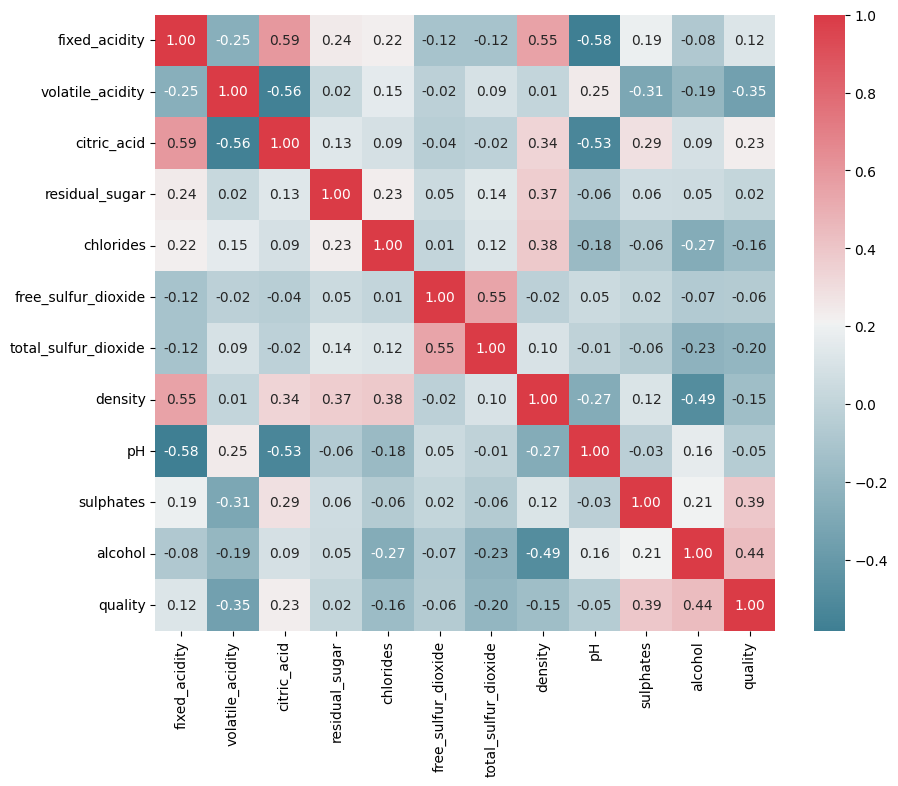

In [ ]:

corr = data.corr()# вставьте сюда полученную матрицу корреляции


f, ax = plt.subplots(figsize=(10, 8)) # создание графика и определение его размеров

cmap = sns.diverging_palette(220, 10, as_cmap=True) # создание палитры для более визуально-понятного отображения корреляций

sns.heatmap(
    corr, # матрица корреляций Пирсона
    cmap=cmap, # палитра
    annot=True, # вывод коэффициентов корреляции
    fmt=".2f" # число знаков после запятой
)

#### **Сделайте вывод**:

После очистики данных была построена матрица корреляций. Как видно на гистограмме, наиболее коррелированными признаками являются:
1) положительная корреляция:
fixed_acidity и citric_acid (что логично, так как с увеличением концентрации кислоты растет кислотность (ツ) ),
fixed_acidity и density (тоже логично, так как кислоты - более плотные жидкости, и с увеличением их содержания увеличивается плотность раствора),
free_sulfur_dioxide и total_sulfur_dioxide (тоже норм, так как даже название признаков об одном и том же почти),
alcohol и quality (корреляция слабая, но все же присутсвует и говорит о том, что чем больше содержание спирта, тем выше качество (ну на это у каждого свои предпочтения (◕‿◕))),
2) отрицательная корреляция:
fixed_acidity и pH (все понятно, чем выше содержание кислот, тем ниже pH),
volatile_acidity и citric_acid (конечно, лимонная кислота связана с кислотностью)
volatile_acidity и quality (корреляция слабая)
citric_acid и pH (тут тоже все ясно)
chlorides и total_sulfur_dioxide слабо коррелируют с alcohol (чем меньше хлоридов и диокисда серы, тем больше спирта)
density и alcohol (тут тоже логично, так как с повышением процентного содержания спирта уменьшается плотность раствора)



#### 5.2 Постройте матрицу нелинейной корреляция фика. Что она показывает, какую информацию мы можем получить?

PS: Более подробнее про корреляцию фика вы можете прочитать на медиуме (нужен VPN) https://medium.com/@asuzukipk/phik-%CF%86k-a-new-and-practical-feature-correlation-1cff226fc5cb или же в оригинальной статье https://arxiv.org/abs/1811.11440

interval columns not set, guessing: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


<Axes: >

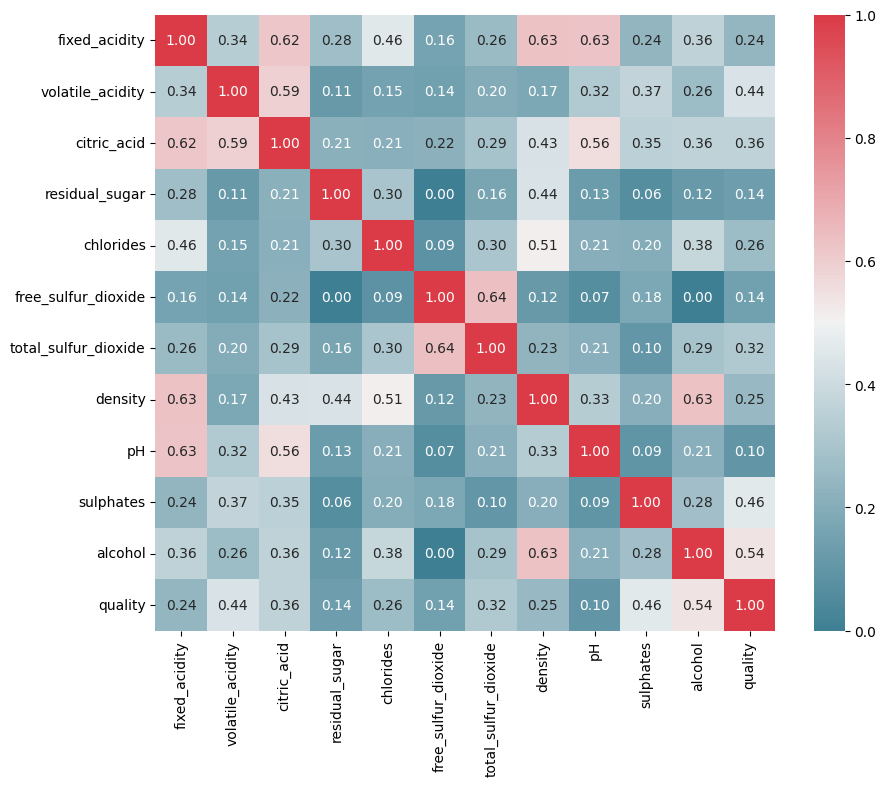

In [ ]:
phik_corr_matrix = data.phik_matrix() # здесь вам необходимо вставить таблицу вместо "df"


f, ax = plt.subplots(figsize=(10, 8)) # создание графика и определение его размеров

cmap = sns.diverging_palette(220, 10, as_cmap=True) # создание палитры для более визуально-понятного отображения корреляций

sns.heatmap(
    phik_corr_matrix, # матрица корреляций фика
    cmap=cmap, # палитра
    annot=True, # вывод коэффициентов корреляции
    fmt=".2f" # число знаков после запятой
)

#### **Сделайте вывод**:

Матрица корреляций фика учитывает также нелинейные связи между признаками, а также лучше работает с категориальными признаками (не наш случай). По сравнению с матрице корреляций Пирсона можно заметить, что на матрицей фика корреляция между некоторыми признаками заметно увеличилась. Например, fixed_acidity и chlorides. В матрице Пирсона - 0.22, в матрице фика - 0.46.
Хотя в остальном мы видим те же пары хорошо коррелрованных признаков.

#### 5.3 С помощью проведенного корреляционного анализа подтвердите или опровергните две нулевые гипотезы:

1. Уровень содержания алкоголя (alcohol) положительно влияет на качество вина (quality)
2. Содержание сахара (residual sugar) существенно влияет на качество вина

#### **Сделайте вывод**:

1. Так как корреляция (Пирсон) признаков alcohol и quality положительна (0.44), можно считать, что уровень содержания положительно влияет на качество вина. Гипотеза подтверждена.
2. Так как корреляция признаков residual_sugar и quality равна 0.13 (фика) и 0.02 (Пирсон), то есть она очень мала, можно считать, что содержание сахара практически на влияет на качество вина. Гипотеза опровергнута.

#### 5.4 С помощью t-тест ответьте на вопрос: *различается ли качество вина с высоким и низким содержанием алкоголя или сахара?*

PS: для начала разделите данные на две группы (группа 1: высокое и низкое содержание алкоголя, группа 2: высокое и низкое содержание сахара). В качестве порогового значения выбираем медиану. Далее выполните t-тест с помощью stats.ttest_ind (более подробнее можно прочитать в документации https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) и сравните полученные p-value с уровнем значимости.


In [ ]:
alcohol_med = data['alcohol'].median()
sugar_med = data['residual_sugar'].median()



data['high_alcohol'] = data['alcohol'] > alcohol_med
data['high_sugar'] = data['residual_sugar'] > sugar_med

group_high_alcohol = data[data['high_alcohol']]['quality']
group_low_alcohol = data[~data['high_alcohol']]['quality']
t_statistic, p_value = stats.ttest_ind(group_high_alcohol, group_low_alcohol)
print(f'T-statistic (Alcohol): {t_statistic}, P-value (Alcohol): {p_value}')

group_high_sugar = data[data['high_sugar']]['quality']
group_low_sugar = data[~data['high_sugar']]['quality']
t_statistic, p_value = stats.ttest_ind(group_high_sugar, group_low_sugar)
print(f'T-statistic (Sugar): {t_statistic}, P-value (Sugar): {p_value}')

T-statistic (Alcohol): 15.510530429088222, P-value (Alcohol): 4.48299221998687e-50
T-statistic (Sugar): 1.1669200186109094, P-value (Sugar): 0.24344768812284398


#### **Сделайте вывод**:

Возьмем уровень значимости стандартным - 0.05.
1. Алкоголь: p-значение много меньше установленного уровня значимости, следовательно гипотиза того, что вина с высоким и низким содержанием алкоголя сильно различаются по качеству, подтверждена.
2. Сахар: p-значение составляет 0.127 (значительно больше уровня значимости) что говорит о малых различиях в качестве между винами с высоким и низким соедражанием сахара.

Эти результаты схожи с теми, что мы получиили при корреляционном анализе.

#### 5.5 Выдвините две гипотезы в данных, опровергните или подвердите их. Сформируйте вопрос о различии и ответьте на него с помощью t-теста

Мои гипотезы:
1. Уровень содержания лимонной кислоты отрицательно влияет на pH вина.
2. Общее содержание диоксида серы существенно влияет на плотность вина.

Вопрос: *различается ли pH вина с высоким и низким содержанием лимонной кислоты? различается ли плотность вина с высоким и низким общим содержанием диоксида серы?*

In [ ]:
ca_med = data['citric_acid'].median()
sd_med = data['total_sulfur_dioxide'].median()

data['high_ca'] = data['citric_acid'] > ca_med
data['high_sd'] = data['total_sulfur_dioxide'] > sd_med

group_high_ca = data[data['high_ca']]['pH']
group_low_ca = data[~data['high_ca']]['pH']
t_statistic, p_value = stats.ttest_ind(group_high_ca, group_low_ca)
print(f'T-statistic (Citric Acid): {t_statistic}, P-value (Citric Acid): {p_value}')

group_high_sd = data[data['high_sd']]['density']
group_low_sd = data[~data['high_sd']]['density']
t_statistic, p_value = stats.ttest_ind(group_high_sd, group_low_sd)
print(f'T-statistic (Sulfur Dioxide): {t_statistic}, P-value (Sulfur Dioxide): {p_value}')

T-statistic (Citric Acid): -16.775783243404028, P-value (Citric Acid): 1.5248692023566422e-57
T-statistic (Sulfur Dioxide): 2.0077632578559803, P-value (Sulfur Dioxide): 0.0448663747528424


#### **Сделайте вывод**:

Возьмем уровень значимости стандартным - 0.05.
1. Корреляция признаков citric_acid и pH отрицательна и равна -0.53 (Пирсон), что свидетельствует об отрицательном влиянии содержания лимонной кислоты на pH. Гипотеза 1 подтверждена. Кроме того t-test показал, что p-значение сильно меньше установаленного уровня значимости, следовательно, pH вин с высоким и низким содержанием лимонной кислоты очень сильно отличается.
2. Корреляция признаков total_sulfur_dioxide и density составляет 0.22 (фика) и 0.11 (Пирсон), что говорит о малом влиянии содержания диоксида серы на плотность (но все же влияние есть). Гипотеза 2 опровергнута. t-test показал, что p-значение составляет 0.0148, что меньше уровня значимости, поэтому можно сказать, что плотность вина с различным содержанием диоксида серы различается, но не сильно, о чем говорит значение T-statistic.

In [ ]:
data = data.drop(columns=['high_alcohol', 'high_sugar', 'high_ca', 'high_sd'])

## **Блок 6: Преобразование данных**

#### 6.1 Есть ли в данных категориальные признаки?

Нет, таких признаков нет.

#### 6.1 Если такие есть, закодируйте их с помощью One-Hot кодирования. Более подробнее как это сделать можно прочитать в документации (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

## **Блок 7: Масштабирование данных**

#### 7.1 С помощью функции df.describe() взгляните на диапазоны. Различаются ли они?

In [ ]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.132649,0.521152,0.271266,2.187539,0.078589,15.763519,44.577358,0.996714,3.306989,0.634327,10.358763,5.615379
std,1.470263,0.167418,0.194365,0.396519,0.014422,9.013873,26.842032,0.001652,0.136689,0.116869,0.992887,0.745792
min,4.600000,0.120000,0.000000,1.200000,0.041000,1.000000,6.000000,0.992350,2.930000,0.330000,8.400000,4.000000
25%,7.100000,0.390000,0.090000,2.000000,0.070000,8.000000,24.000000,0.995655,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,15.000000,38.000000,0.996750,3.310000,0.620000,10.100000,6.000000
75%,9.000000,0.630000,0.430000,2.400000,0.086000,21.000000,58.500000,0.997800,3.390000,0.700000,11.000000,6.000000
max,12.300000,1.010000,0.790000,3.450000,0.119000,47.000000,125.000000,1.001000,3.680000,0.990000,13.200000,7.000000


#### **Сделайте вывод**:

Да, очевидно, диапазоны для разных признаков различаются.

#### 7.2 Используйте любой способ масштабирования данных из предложенных в лекции (слайд 50, 51)

Подсказка: Большая часть способов масштабирования данных представлено в бибилотеке scikit-learn (более детальную реализацию можно посмотреть здесь https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler)

Видно, что почти все признаки нормально распределенны (или хотя бы похожи на нормальное распределение), поэтому я применю StandartScaler для масштабирования, так как это приведет к данные к нулевому среднему и единичной дисперсии.

In [ ]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_values, columns=data.columns)
scaled_data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03,1.359000e+03
mean,-5.228423e-16,-3.659896e-16,1.045685e-17,1.254822e-16,-4.182739e-17,5.228423e-17,2.718780e-16,2.129014e-14,5.123855e-15,-6.535529e-17,-2.718780e-16,-2.091369e-16
std,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00,1.000368e+00
min,-2.403617e+00,-2.396984e+00,-1.396164e+00,-2.491437e+00,-2.607413e+00,-1.638469e+00,-1.437729e+00,-2.643298e+00,-2.759033e+00,-2.604950e+00,-1.973521e+00,-2.166788e+00
25%,-7.026153e-01,-7.836645e-01,-9.329473e-01,-4.731372e-01,-5.958095e-01,-8.616026e-01,-7.668917e-01,-6.415412e-01,-7.098262e-01,-7.218126e-01,-8.652335e-01,-8.254380e-01
50%,-1.582946e-01,-6.881000e-03,-5.798256e-02,3.143767e-02,2.848126e-02,-8.473605e-02,-2.451297e-01,2.167328e-02,2.203348e-02,-1.226326e-01,-2.607129e-01,5.159118e-01
75%,5.901464e-01,6.503974e-01,8.169822e-01,5.360125e-01,5.140407e-01,5.811496e-01,5.188790e-01,6.576324e-01,6.075212e-01,5.621447e-01,6.460680e-01,5.159118e-01
max,2.835469e+00,2.920995e+00,2.669849e+00,3.185031e+00,2.803107e+00,3.466654e+00,2.997249e+00,2.595794e+00,2.729914e+00,3.044462e+00,2.862644e+00,1.857262e+00
